## FIFA World Cup 2026 Team's Flight Travel Analysis

In [1]:
from airports import airport_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot
import kagglehub
import warnings
warnings.filterwarnings('ignore')

The FIFA World Cup 2026 is being hosted by 3 different nations: USA, Canada, and Mexico. With stadiums spanning the entire North America continent, teams would have to travel to different locations for their matches. Although not crossing time zones, travel fatigue may be a factor to a team's performance.

The aim of this analysis is to determine whether the travel distance for a team has had an impact on their performance in the FIFA World Cup 2026. Both the travel distance for an individual match, and the total distance a team travelled is analysed. The analysis only calculates flight times, and does not include travelling between airport to hotels, and stadiums. It assumes a team starts at their first match location, and ends at their last group stage match location.

In [2]:
# Data import
df_host_cities = pd.read_csv('data/FIFAWorldCup2026/host_cities.csv')
df_matches = pd.read_csv('data/FIFAWorldCup2026/matches.csv')
df_teams = pd.read_csv('data/FIFAWorldCup2026/teams.csv')

In [3]:
#Data cleaning wrangling

#Creates new dataframe with only airport code of cities
df_host_cities = df_host_cities[['id', 'airport_code']]
df_host_cities

#Change data types
df_matches = df_matches.astype({'home_team_id': 'Int64', 'away_team_id': 'Int64'})
#Creates new dataframe with only relevant information
df_matches = df_matches[['home_team_id', 'away_team_id', 'city_id', 'stage_id']]
#Selects group stage matches
df_group_matches = df_matches[df_matches['stage_id'] == 1]
df_group_matches

#Replace Placeholder Names with Team Names
df_teams.loc[df_teams['team_name'] == 'Winner UEFA Playoff A', ['team_name', 'fifa_code']] = ['Bosnia and Herzegovina', 'BIH']
df_teams.loc[df_teams['team_name'] == 'Winner UEFA Playoff B', ['team_name', 'fifa_code']] = ['Sweden', 'SWE']
df_teams.loc[df_teams['team_name'] == 'Winner UEFA Playoff C', ['team_name', 'fifa_code']] = ['Türkiye', 'TUR']
df_teams.loc[df_teams['team_name'] == 'Winner UEFA Playoff D', ['team_name', 'fifa_code']] = ['Czhecia', 'CZE']
df_teams.loc[df_teams['team_name'] == 'Winner FIFA Playoff 1', ['team_name', 'fifa_code']] = ['DR Congo', 'COD']
df_teams.loc[df_teams['team_name'] == 'Winner FIFA Playoff 2', ['team_name', 'fifa_code']] = ['Iraq', 'IRQ']
df_teams = df_teams[['id', 'team_name', 'fifa_code']]

#Creates a list of teams
team_list = []
for team in df_teams['team_name']:
    team_list.append(team)

#Creates a list of teams that were knocked out at group stages
team_knocked_out = ['Czhecia', 'Qatar', 'Haiti', 'Türkiye', 'Curaçao', 'Tunisia', 'New Zealand', 'Saudi Arabia', 'Iraq',
                    'Jordan', 'Ubekistan', 'Panama', 'IR Iran', 'South Korea', 'Scotland', 'Uruguay']

#Creates a list of winners of each game, chronologically. 1=Home Team, 2=Away Team, 3=Draw
match_winners = [1, 1, 3, 1, 3, 3, 2, 1, 1, 3, 1, 1, 3, 3, 3, 3, 1, 2, 1, 1, 3, 1, 1, 2, 3, 1, 1, 1, 1, 2, 1, 2, 1, 1, 3, 2,
                 1, 3, 3, 2, 1, 1, 1, 2, 1, 3, 2, 1, 1, 1, 1, 2, 1, 2, 2, 1, 2, 3, 1, 3, 2, 1, 3, 2, 2, 3, 2, 1, 3, 1, 3, 2]

In [4]:
#Merges dataframes together
df = pd.merge(df_matches, df_host_cities, left_on='city_id', right_on='id', how='left')
df.drop('id', axis=1, inplace=True)
df = pd.merge(df, df_teams, left_on='home_team_id', right_on='id')
df.rename(columns={'team_name': 'home_team_name', 'fifa_code': 'home_team_fifa_code'}, inplace=True)
df = pd.merge(df, df_teams, left_on='away_team_id', right_on='id')
df.rename(columns={'team_name': 'away_team_name', 'fifa_code': 'away_team_fifa_code'}, inplace=True)
df.drop(['home_team_id', 'away_team_id', 'id_x', 'id_y'], axis=1, inplace=True)

#Select only group stage matches
df_group_matches = df[df['stage_id'] == 1]
df_group_matches

#Create Winner Column
df_group_matches['winning_team'] = match_winners
df_group_matches['winning_team'] = np.where(
    df_group_matches['winning_team'] == 1,
    df_group_matches['home_team_name'],
    np.where(
        df_group_matches['winning_team'] == 2,
        df_group_matches['away_team_name'],
        'Draw'
    )
)

In [5]:
#Creates dictionary for each team games
team_matches = {}
for team in team_list:
    team_matches[team] = df_group_matches[
        (df_group_matches['home_team_name'] == team) |
        (df_group_matches['away_team_name'] == team)
    ]

#Calculates total distance traveled and creates new Dataframe
team_distance = []
for team in team_matches:
    airport_codes = team_matches[team]['airport_code'].tolist()
    distance1 = airport_data.calculate_distance(airport_codes[0], airport_codes[1])
    win1 = team_matches[team]['winning_team'].iloc[1]
    distance2 = airport_data.calculate_distance(airport_codes[1], airport_codes[2])
    win2 = team_matches[team]['winning_team'].iloc[2]
    total_distance = distance1 + distance2
    knocked_out = 0
    if team in team_knocked_out:
        knocked_out = 1
    team_distance.append([team, distance1, win1, distance2, win2, total_distance, knocked_out])
df_distance = pd.DataFrame(team_distance, columns=['Team', 'Distance 1', 'Winning Team 1', 'Distance 2', 'Winning Team 2', 'Total Distance', 'Knocked Out'])

### Travel Distance for each Individual Match and Match Outcome

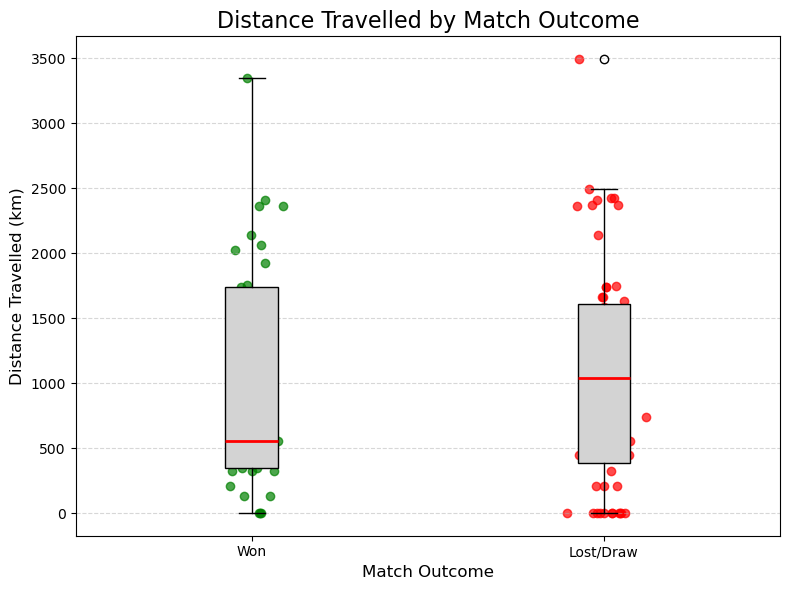

In [6]:
from matplotlib.patches import Patch
#Match 1
match1 = pd.DataFrame({
    'Distance': df_distance['Distance 1'],
    'Won': (df_distance['Winning Team 1'] == df_distance['Team']).astype(int)
})

#Match 2
match2 = pd.DataFrame({
    'Distance': df_distance['Distance 2'],
    'Won': (df_distance['Winning Team 2'] == df_distance['Team']).astype(int)
})

#Combine the two matches
df_matches = pd.concat([match1, match2], ignore_index=True)

#Create colours from the combined dataframe
colors = df_matches['Won'].map({
    1: 'green',
    0: 'red'
})

won = df_matches[df_matches['Won'] == 1]['Distance']
lost = df_matches[df_matches['Won'] == 0]['Distance']

plt.figure(figsize=(8, 6))

plt.boxplot(
    [won, lost],
    tick_labels=['Won', 'Lost/Draw'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgray'),
    medianprops=dict(color='red', linewidth=2)
)

# Add jittered points
plt.scatter(
    np.random.normal(1, 0.04, len(won)),
    won,
    color='green',
    alpha=0.7
)

plt.scatter(
    np.random.normal(2, 0.04, len(lost)),
    lost,
    color='red',
    alpha=0.7
)

plt.ylabel('Distance Travelled (km)', fontsize=12)
plt.xlabel('Match Outcome', fontsize=12)
plt.title('Distance Travelled by Match Outcome', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The box plot compares the travel distances of teams that won matches with those that lost or drew. The median travel distance was lower for winning teams (approximately 550 km) than for teams that lost or drew (approximately 1050 km), suggesting that winning teams generally travelled shorter distances before matches. However, the interquartile ranges of the two groups overlapped substantially, indicating considerable variability in travel distances regardless of match outcome. Furthermore, both groups contained teams that travelled over 2000 km, including observations exceeding 3000 km. Overall, the box plot provides only weak visual evidence that greater travel distance is associated with poorer match performance.

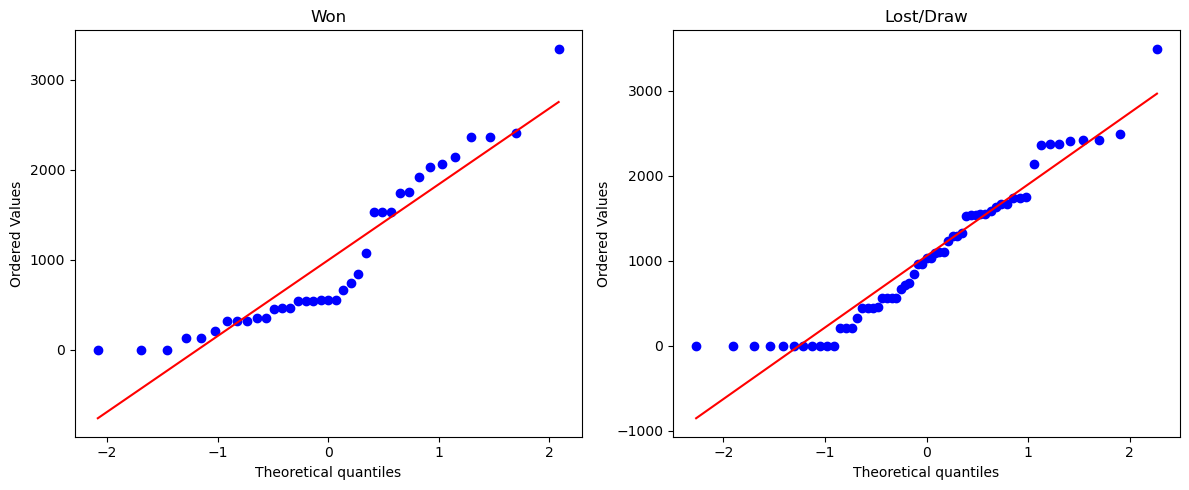

In [7]:
#Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

probplot(won, dist="norm", plot=axes[0])
axes[0].set_title("Won")

probplot(lost, dist="norm", plot=axes[1])
axes[1].set_title("Lost/Draw")

plt.tight_layout()
plt.show()

Visual assessment of the Q-Q plots indicated that the travel distance distributions for both the Won and Lost/Draw groups deviated from normality. Both groups showed systematic departures from the reference line, particularly in the lower and upper tails, along with several extreme observations. Consequently, the assumption of normality required for an independent-samples t-test was not satisfied. Therefore, a Mann–Whitney U test was selected to compare travel distances between the two groups.

In [8]:
from scipy.stats import mannwhitneyu

# Separate the two groups
won = df_matches[df_matches['Won'] == 1]['Distance']
lost = df_matches[df_matches['Won'] == 0]['Distance']

# Mann-Whitney U test
u_stat, p_value = mannwhitneyu(
    won,
    lost,
    alternative='two-sided'
)

print(f"U Statistic: {u_stat:.3f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05

if p_value < alpha:
    print("\nReject the null hypothesis.")
    print("There is a statistically significant difference in travel distance between matches that were won and those that were lost/drawn.")
else:
    print("\nFail to reject the null hypothesis.")
    print("There is no statistically significant difference in travel distance between matches that were won and those that were lost/drawn.")

U Statistic: 1038.000
P-value: 0.6894

Fail to reject the null hypothesis.
There is no statistically significant difference in travel distance between matches that were won and those that were lost/drawn.


In [9]:
#Median
print(f"Median Total Distance (Advanced): {won.median():.2f} km")
print(f"Median Total Distance (Knocked Out): {lost.median():.2f} km")
#Effect Size
n1 = len(won)
n2 = len(lost)

rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print(f"Rank-biserial correlation: {rank_biserial:.3f}")

Median Total Distance (Advanced): 556.80 km
Median Total Distance (Knocked Out): 1036.82 km
Rank-biserial correlation: 0.049


The Mann–Whitney U test found no statistically significant difference in travel distance between matches that were won and those that were lost or drawn (p > 0.05). Furthermore, the rank-biserial correlation was 0.049, indicating a negligible effect size. Together, these findings suggest that travel distance was not meaningfully associated with match outcomes during the group stage.

### Total Distance Travelled and Group Stage Advancement

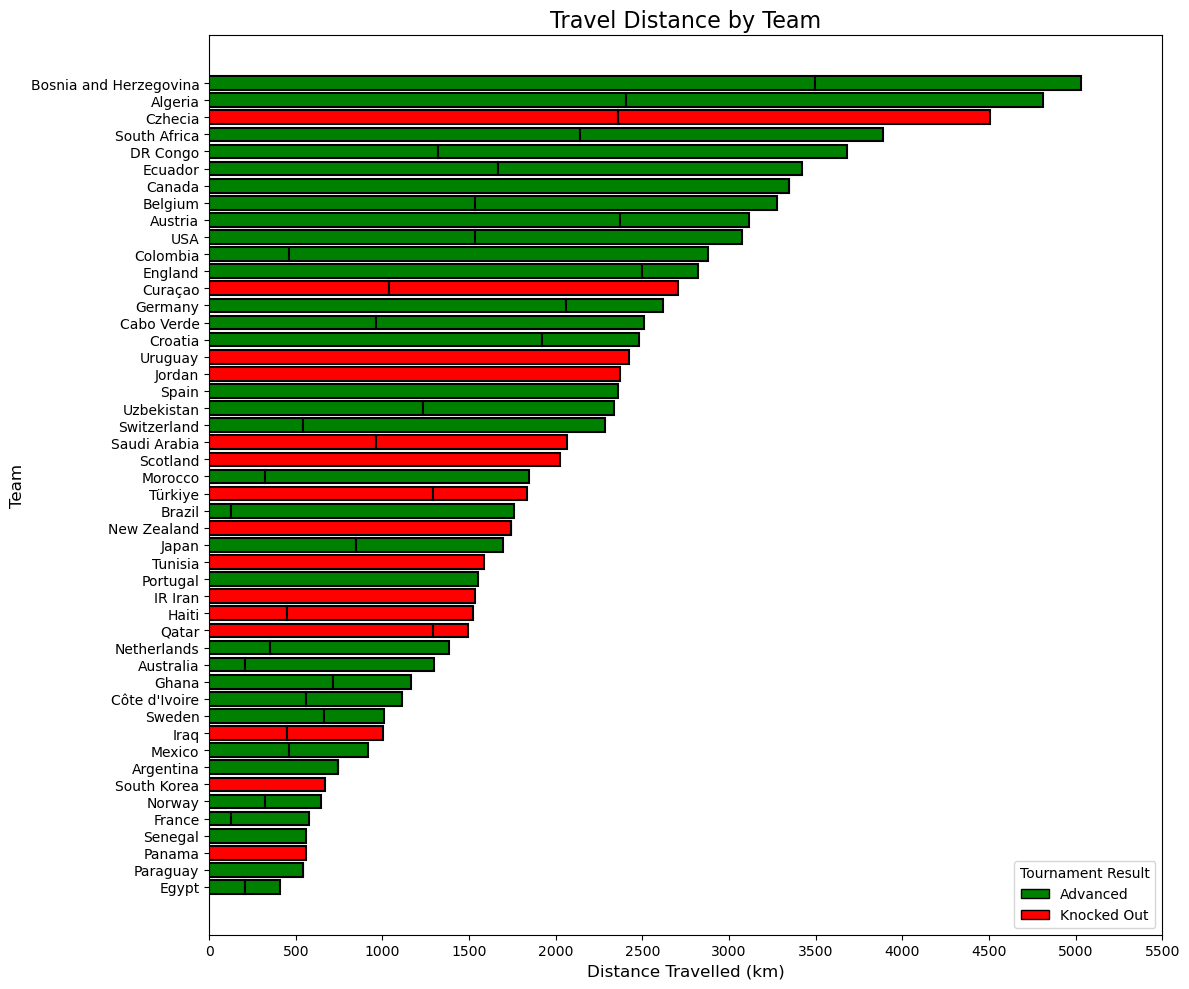

In [10]:
#Plot for visual representation
# Sort by total distance
df_plot = df_distance.sort_values('Total Distance')

# Assign colours based on knockout status
colors = df_plot['Knocked Out'].map({
    0: 'green',
    1: 'red'
})

# Maximum distance for x-axis ticks
max_dist = df_plot['Total Distance'].max()

plt.figure(figsize=(12, 10))

# Plot Distance 1
plt.barh(
    df_plot['Team'],
    df_plot['Distance 1'],
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

# Plot Distance 2
plt.barh(
    df_plot['Team'],
    df_plot['Distance 2'],
    left=df_plot['Distance 1'],
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

# Labels
plt.xlabel('Distance Travelled (km)', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.title('Travel Distance by Team', fontsize=16)

# X-axis ticks every 500 km
plt.xticks(np.arange(0, max_dist + 500, 500))

# Legend
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='Advanced'),
    Patch(facecolor='red', edgecolor='black', label='Knocked Out')
]

plt.legend(handles=legend_elements, title='Tournament Result', loc='lower right')

plt.tight_layout()
plt.show()

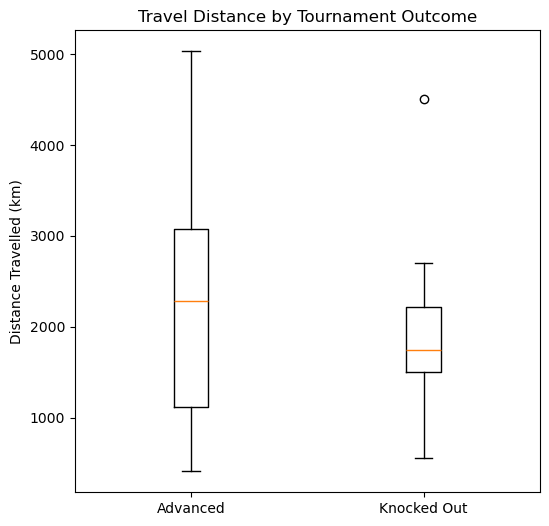

In [11]:
#Box plot of knockout status and travel distance
advanced = df_distance[df_distance['Knocked Out']==0]['Total Distance']
knocked_out = df_distance[df_distance['Knocked Out']==1]['Total Distance']

plt.figure(figsize=(6,6))
plt.boxplot([advanced, knocked_out],
            tick_labels=['Advanced', 'Knocked Out'])

plt.ylabel('Distance Travelled (km)')
plt.title('Travel Distance by Tournament Outcome')

plt.show()

The median between the groups show that Knocked Out teams travelled less than the teams that Advanced. The Advanced group is positively skewed, as a lot of teams that Advanced also had to travel a lot. There appears to be an outlier in the Knocked Out group. Since the boxes overlap, it indicates that travel distance does not have an impact on a team's performance.

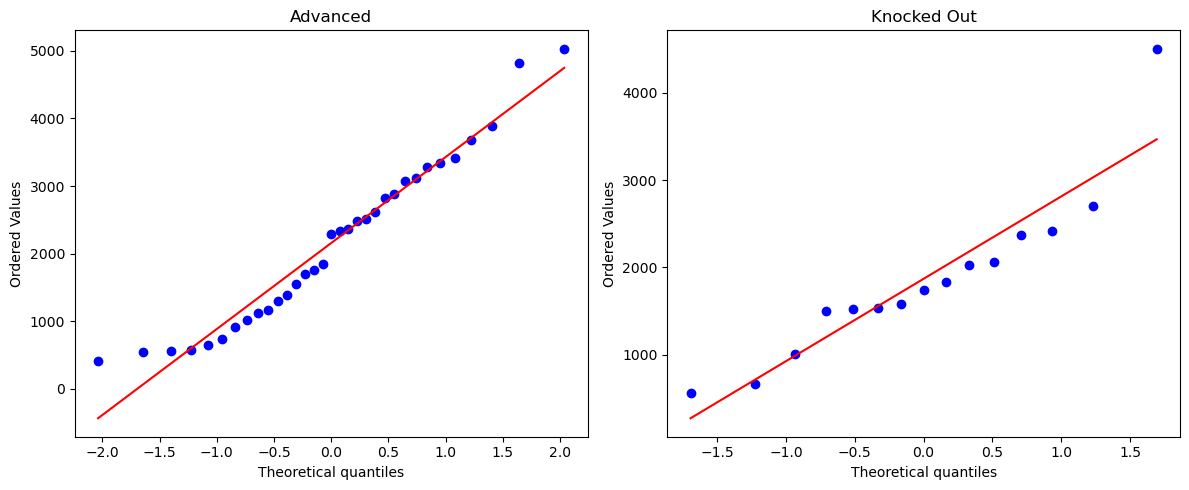

In [13]:
#Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

probplot(advanced, dist="norm", plot=axes[0])
axes[0].set_title("Advanced")

probplot(knocked_out, dist="norm", plot=axes[1])
axes[1].set_title("Knocked Out")

plt.tight_layout()
plt.show()

Visual inspection of the Q-Q plots indicated that the distributions of total travel distance for both the Advanced and Knocked Out groups were approximately normal. Most observations closely followed the reference line, with only minor departures in the tails. Although a small number of high-distance observations were present, there was no evidence of severe non-normality.

In [14]:
from scipy.stats import ttest_ind
#Welch's independent-samples t-test
t_stat, p_value = ttest_ind(
    advanced,
    knocked_out,
    equal_var=False
)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

#Interpretation
alpha = 0.05

if p_value < alpha:
    print("\nReject the null hypothesis.")
    print("There is a statistically significant difference in total travel distance between teams that advanced and those that were knocked out.")
else:
    print("\nFail to reject the null hypothesis.")
    print("There is no statistically significant difference in total travel distance between teams that advanced and those that were knocked out.")

T-statistic: 0.874
P-value: 0.3882

Fail to reject the null hypothesis.
There is no statistically significant difference in total travel distance between teams that advanced and those that were knocked out.


In [15]:
print("Advanced")
print(f"Mean: {advanced.mean():.2f} km")
print(f"SD: {advanced.std(ddof=1):.2f} km")
print(f"n = {len(advanced)}")

print("\nKnocked Out")
print(f"Mean: {knocked_out.mean():.2f} km")
print(f"SD: {knocked_out.std(ddof=1):.2f} km")
print(f"n = {len(knocked_out)}")

Advanced
Mean: 2156.08 km
SD: 1253.18 km
n = 33

Knocked Out
Mean: 1869.26 km
SD: 950.28 km
n = 15


In [16]:
#Effect Size
mean1 = advanced.mean()
mean2 = knocked_out.mean()

sd1 = advanced.std(ddof=1)
sd2 = knocked_out.std(ddof=1)

n1 = len(advanced)
n2 = len(knocked_out)

# Pooled standard deviation
pooled_sd = np.sqrt(
    ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2) /
    (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_sd

print(f"Cohen's d: {cohens_d:.3f}")

Cohen's d: 0.245


An independent-samples t-test was conducted to compare the total travel distances of teams that advanced beyond the group stage with those that were knocked out. Teams that advanced travelled a greater mean distance (M = 2156.08 km, SD = 1253.18 km) than teams that were knocked out (M = 1869.26 km, SD = 950.28 km). However, this difference was not statistically significant, t = 0.874, p = .388. The effect size was small (Cohen's d = 0.245), indicating that the difference in travel distance between the two groups had little practical significance. These findings suggest that total travel distance was not associated with progression beyond the group stage.